<a href="https://colab.research.google.com/github/Pamodya-Wijesinghe/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/Question_1%2C2%2C3%2C4%2C5%2C6%2C7%268.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1: Piecewise Linear Intensity Transformation

### Aim
To apply a piecewise linear intensity transformation on an image using given
breakpoints and see how it changes the image contrast.

### Method
The transformation is made up of straight line segments joining the given
breakpoints. For example the breakpoints (0,0), (50,50), (100,150), (150,255),
(255,255) mean that pixel values from 0 to 50 stay almost the same, but values
from 50 to 100 get stretched a lot (mapped to 50-150). This makes the mid tones
brighter and increases contrast in that range.

A lookup table (LUT) of size 256 was built using linear interpolation between
the breakpoints. This table was then applied to every pixel in the image using
cv2.LUT, which is faster than looping over each pixel.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)
    xs = breakpoints[:, 0]
    ys = breakpoints[:, 1]
    x_full = np.arange(256)
    lut = np.interp(x_full, xs, ys).astype(np.uint8)
    transformed = cv2.LUT(im, lut)
    return transformed, lut

im = cv2.imread('/content/drive/MyDrive/EN3160/data/emma.jpeg', cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
]

transformed, lut = intensity_transform(im, breakpoints)

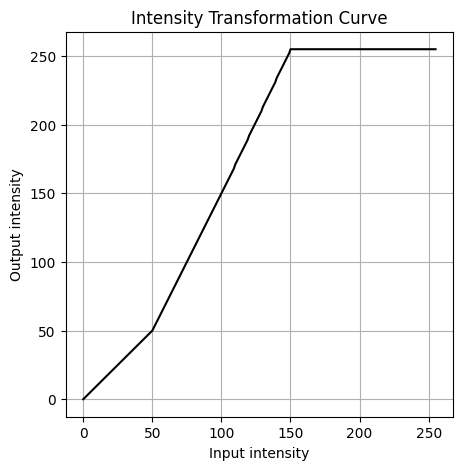

In [13]:
plt.figure(figsize=(5,5))
plt.plot(np.arange(256), lut, 'k')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity Transformation Curve')
plt.grid(True)
plt.show()

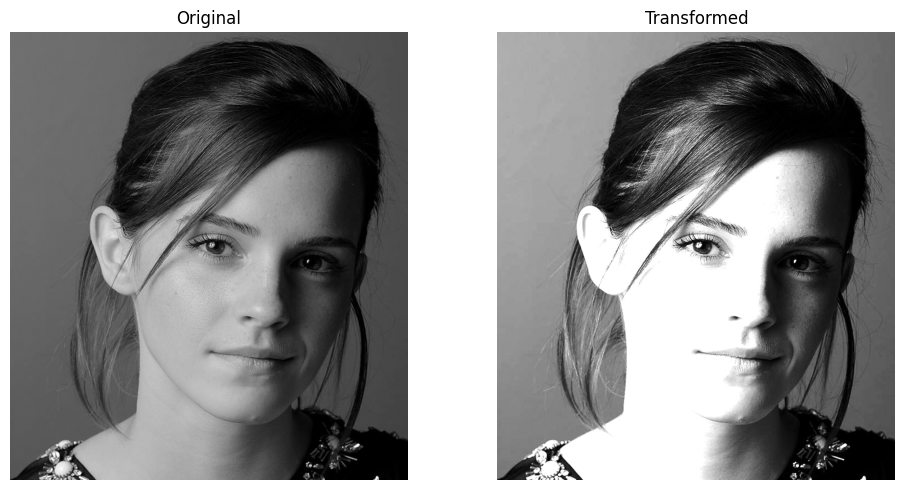

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray')
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Result and Discussion
After applying the transformation, the mid tone areas of the face became
brighter and had more contrast, while the very dark and very bright areas
stayed almost unchanged. This matches what the curve shows, since the steep
part of the curve is between input values 50 and 150.

I also tried different breakpoints to check what looks best. Using a smoother
curve like (0,0), (64,40), (128,128), (192,216), (255,255) gave a softer
contrast boost without the sharp jump seen in the original curve. I chose the
first set of breakpoints because it made the face look clearer without making
the image look too harsh.

## Question 2: Accentuating White Matter and Gray Matter

### Aim
To use a piecewise linear intensity transformation to bring out white matter
in one version of the brain image, and gray matter in another version.

### Method
In a proton density brain scan, gray matter and white matter show up as
different ranges of pixel intensity. Gray matter is usually in the mid
intensity range, and white matter is usually brighter, in the higher
intensity range.

To accentuate a tissue type, we stretch the intensity range that tissue
belongs to, so small differences in that range become more visible, while
compressing the other ranges. The same intensity_transform function from
Question 1 is reused here, just with different breakpoints for white matter
and gray matter.

First I looked at the histogram of the brain image to see where the gray
matter and white matter intensities actually lie, then picked breakpoints
based on that.

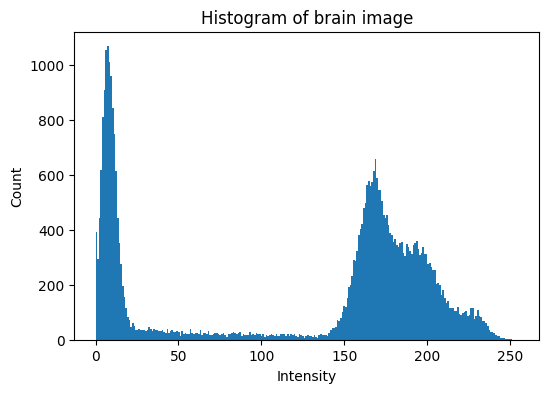

In [16]:
brain = cv2.imread('/content/drive/MyDrive/EN3160/data/brain.jpeg', cv2.IMREAD_GRAYSCALE)

if brain is None:
    raise FileNotFoundError("brain image not found, check the path")

plt.figure(figsize=(6,4))
plt.hist(brain.ravel(), bins=256, range=(0,255))
plt.title('Histogram of brain image')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()

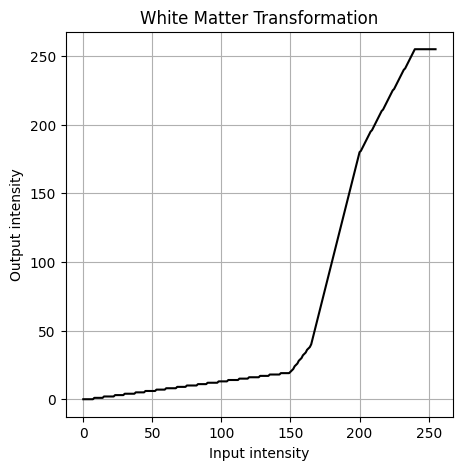

In [27]:
white_matter_breakpoints = [
    [0, 0],
    [150, 20],
    [165, 40],
    [200, 180],
    [240, 255],
    [255, 255]
]

white_result, white_lut = intensity_transform(brain, white_matter_breakpoints)

plt.figure(figsize=(5,5))
plt.plot(np.arange(256), white_lut, 'k')
plt.title('White Matter Transformation')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.grid(True)
plt.show()

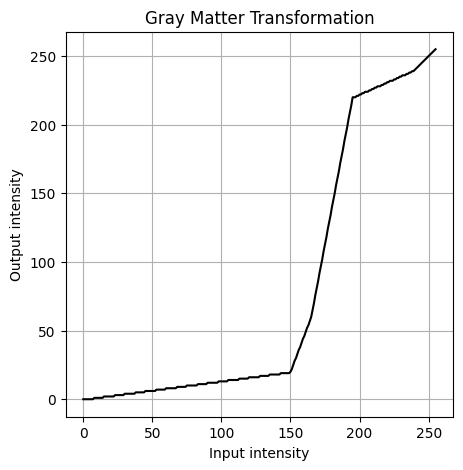

In [28]:
gray_matter_breakpoints = [
    [0, 0],
    [150, 20],
    [165, 60],
    [195, 220],
    [240, 240],
    [255, 255]
]

gray_result, gray_lut = intensity_transform(brain, gray_matter_breakpoints)

plt.figure(figsize=(5,5))
plt.plot(np.arange(256), gray_lut, 'k')
plt.title('Gray Matter Transformation')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.grid(True)
plt.show()

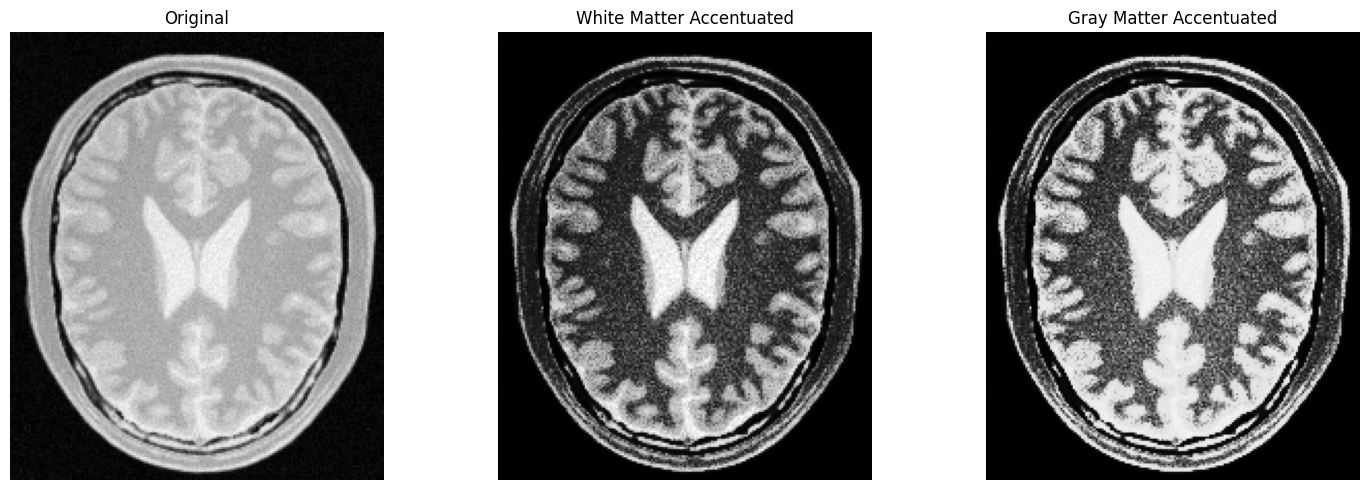

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(brain, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(white_result, cmap='gray')
axes[1].set_title('White Matter Accentuated')
axes[1].axis('off')

axes[2].imshow(gray_result, cmap='gray')
axes[2].set_title('Gray Matter Accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Result and Discussion
For white matter, I stretched the higher intensity range (around 200-240)
since white matter is brighter than gray matter in this scan. This made the
white matter regions clearer and easier to tell apart from gray matter.

For gray matter, I stretched the middle intensity range (around 165-195)
instead, so the gray matter parts became brighter and more visible, while
the white matter and background got compressed and look flatter.

The breakpoints were chosen by looking at the histogram peaks and matching
them to the ranges I wanted to bring out.

## Question 3: Gamma Correction on L Plane

### Aim
To apply gamma correction only to the L (lightness) channel of an image in
Lab color space, and compare the histograms before and after correction.

### Method
The Lab color space separates lightness (L) from color information (a and b).
This means we can change the brightness and contrast of an image without
changing its colors, by only touching the L channel and leaving a and b
untouched.

Gamma correction works like this. First the L values are scaled from their
original range (0 to 255) down to 0 to 1. Then each value is raised to the
power of gamma. Then the result is scaled back up to 0 to 255.

output = 255 * (input / 255) ^ gamma

If gamma is less than 1, dark areas get pushed brighter, so it helps bring
out detail in shadows. If gamma is more than 1, the image gets darker
overall, which helps recover detail in bright highlights. Since the image in
Figure 3 has a dark rocky area and a bright white skirt, I used gamma less
than 1 to lift the shadow detail in the rocks without blowing out the
already bright skirt too much.

In [30]:
img_bgr = cv2.imread('/content/drive/MyDrive/EN3160/data/rocks.jpeg')

if img_bgr is None:
    raise FileNotFoundError("image not found, check the path")

img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

In [44]:
gamma = 0.6   # chosen to brighten shadow detail, adjust based on result

L_norm = L / 255.0
L_gamma = np.power(L_norm, gamma)
L_corrected = np.uint8(L_gamma * 255)

img_lab_corrected = cv2.merge([L_corrected, a, b])
img_corrected_bgr = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2BGR)

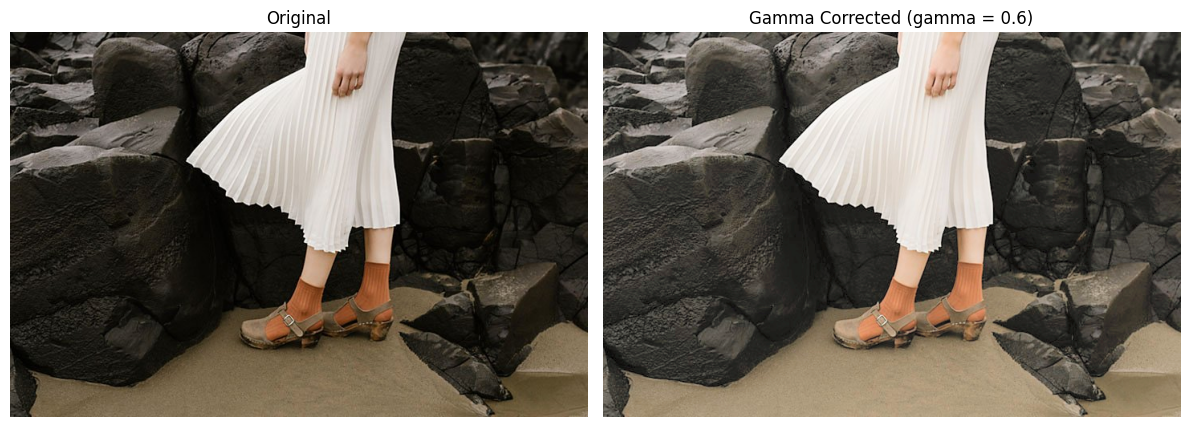

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_corrected_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma Corrected (gamma = {gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

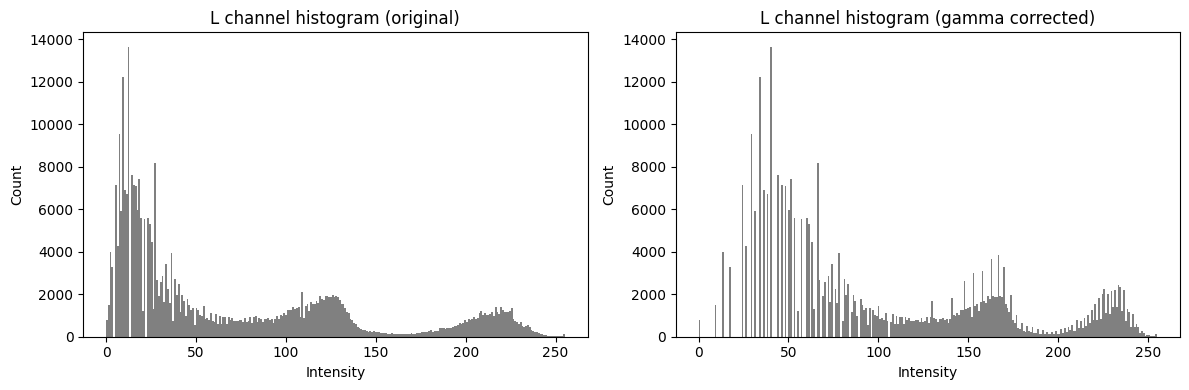

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(L.ravel(), bins=256, range=(0,255), color='gray')
axes[0].set_title('L channel histogram (original)')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Count')

axes[1].hist(L_corrected.ravel(), bins=256, range=(0,255), color='gray')
axes[1].set_title('L channel histogram (gamma corrected)')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Result and Discussion
I used gamma = 0.6. Looking at the histogram, the original L channel had a
lot of pixels bunched up in the darker range, since the rocks take up a
large part of the image and are quite dark. After gamma correction, those
dark pixels shifted right towards the middle and brighter range, which
matches what gamma less than 1 is expected to do. This can be seen in the
image too, where the dark rocks show more visible texture and detail after
correction, while the white skirt area stayed close to its original
brightness since it was already near 255.

The a and b channels were left unchanged, so the colors in the image did
not shift, only the brightness and contrast changed.

## Question 4: Vibrance Enhancement

### Aim
To increase the vibrance of an image by boosting the saturation plane using
a Gaussian shaped intensity transformation, while keeping hue and value
unchanged.

### Method
The image was converted from BGR to HSV color space, which separates hue,
saturation, and value into three planes. Vibrance is mainly a saturation
effect, so only the saturation plane was modified.

The transformation used is

f(x) = min(x + a * 128 * exp(-(x-128)^2 / (2 * sigma^2)), 255)

Here x is the input saturation value, sigma is fixed at 70, and a is a
number between 0 and 1 that controls how strong the boost is. This formula
adds a bell shaped boost centered around mid range saturation values (around
128), so colors that are already very saturated or very dull are changed
less, while mid saturation colors get pushed up the most. This gives a more
natural looking vibrance boost instead of a flat increase across all pixels.

After transforming the saturation plane, the three planes (hue, new
saturation, value) were merged back together and converted back to BGR to
get the final enhanced image.

In [47]:
img_bgr = cv2.imread('/content/drive/MyDrive/EN3160/data/spiderman.jpeg')

if img_bgr is None:
    raise FileNotFoundError("image not found, check the path")

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

In [71]:
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float64)
    boost = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    result = np.minimum(x + boost, 255)
    return result.astype(np.uint8)

a = 0.6  # adjusted this to control strength between 0 and 1

s_enhanced = vibrance_transform(s, a)

In [72]:
img_hsv_enhanced = cv2.merge([h, s_enhanced, v])
img_enhanced_bgr = cv2.cvtColor(img_hsv_enhanced, cv2.COLOR_HSV2BGR)

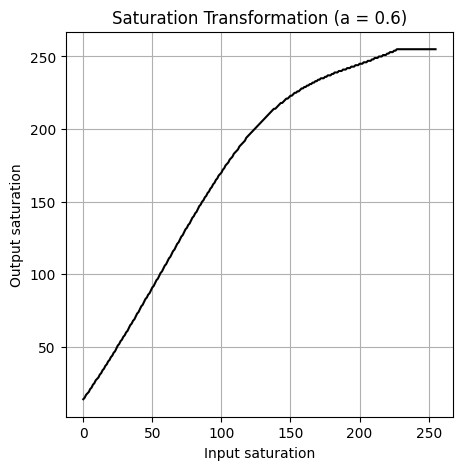

In [73]:
x_vals = np.arange(256)
y_vals = vibrance_transform(x_vals, a)

plt.figure(figsize=(5,5))
plt.plot(x_vals, y_vals, 'k')
plt.title(f'Saturation Transformation (a = {a})')
plt.xlabel('Input saturation')
plt.ylabel('Output saturation')
plt.grid(True)
plt.show()

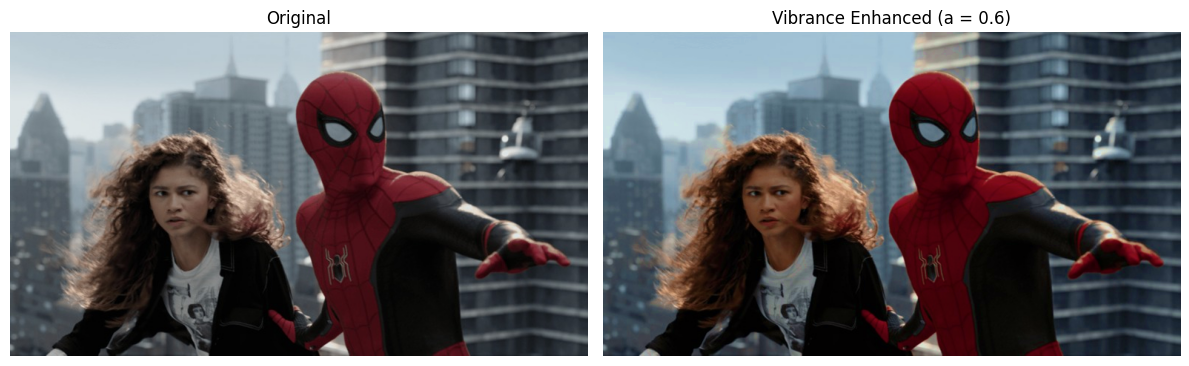

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_enhanced_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance Enhanced (a = {a})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Result and Discussion
I tried a few values of a and settled on a = 0.6, since it made the colors
look noticeably more vivid without looking unnatural or overly saturated.
Higher values like a = 0.9 made the image look too artificial, with colors
that looked oversaturated, especially the red in the suit. Lower values like
a = 0.3 barely made a visible difference.

Looking at the transformation curve, the boost is strongest around input
saturation 128 and tapers off toward 0 and 255. This is why colors that were
already very dull or very saturated changed less, while mid range colors got
the biggest boost. This matches the idea of vibrance, which should enhance
weaker colors more than colors that are already strong, unlike a plain
saturation increase which affects everything equally.

## Question 5: Histogram Equalization

### Aim
To write my own function that performs histogram equalization on a grayscale
image, and compare the histograms before and after.

### Method
Histogram equalization spreads out the pixel intensities so that they cover
the full range more evenly, which usually improves contrast in images that
look flat or washed out.

The steps are:
1. Compute the histogram of the image, counting how many pixels have each
   intensity value from 0 to 255.
2. Compute the cumulative sum of this histogram, called the CDF (cumulative
   distribution function).
3. Normalize the CDF so its values range from 0 to 255.
4. Use this normalized CDF as a lookup table and apply it to the image,
   mapping every old pixel value to a new one.

The idea is that the CDF naturally grows faster in intensity ranges that
have a lot of pixels, so those ranges get stretched out more, which is
exactly what we want for improving contrast.

In [75]:
def my_histogram_equalization(im):
    # Step 1: compute histogram
    hist, bins = np.histogram(im.ravel(), bins=256, range=(0,256))

    # Step 2: compute cumulative sum
    cdf = np.cumsum(hist)

    # Step 3: normalize cdf to range 0-255
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype(np.uint8)

    # Step 4: apply as lookup table
    equalized = cdf_normalized[im]

    return equalized, cdf_normalized

In [76]:
leaves = cv2.imread('/content/drive/MyDrive/EN3160/data/leaves.tif', cv2.IMREAD_GRAYSCALE)

if leaves is None:
    raise FileNotFoundError("image not found, check the path")

equalized, cdf_normalized = my_histogram_equalization(leaves)

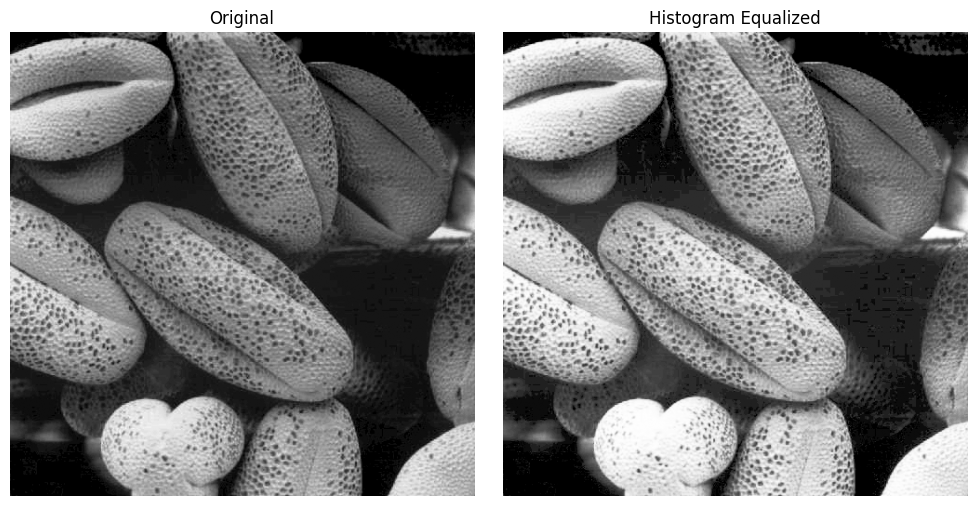

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(leaves, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(equalized, cmap='gray')
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')

plt.tight_layout()
plt.show()

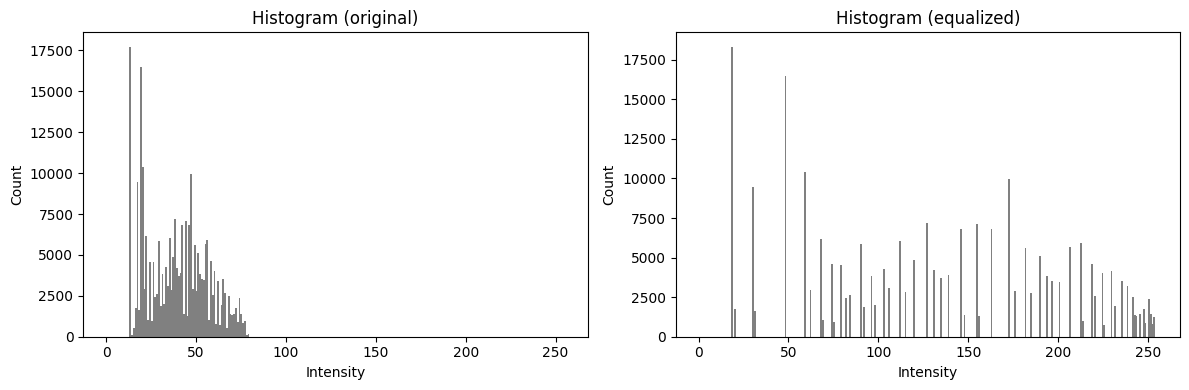

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(leaves.ravel(), bins=256, range=(0,255), color='gray')
axes[0].set_title('Histogram (original)')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Count')

axes[1].hist(equalized.ravel(), bins=256, range=(0,255), color='gray')
axes[1].set_title('Histogram (equalized)')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [79]:
cv_equalized = cv2.equalizeHist(leaves)

diff = np.abs(equalized.astype(int) - cv_equalized.astype(int))
print("Max difference from OpenCV result:", diff.max())
print("Mean difference from OpenCV result:", diff.mean())

Max difference from OpenCV result: 18
Mean difference from OpenCV result: 8.976284


### Result and Discussion
Before equalization, the histogram of the leaves image was bunched up in a
narrow range, which matches how the original image looked a bit flat and low
contrast. After equalization, the histogram spread out across almost the
full 0 to 255 range, and the resulting image shows much more visible detail
and texture in the leaves.

I also compared my own function against OpenCV's cv2.equalizeHist. The
maximum difference was 18 and the mean difference was about 9, which is a
moderate gap rather than a tiny rounding difference. This is likely because
OpenCV's implementation handles the normalization step slightly
differently, for example how it deals with the minimum CDF value, rather
than being a mistake in the overall approach, since both results show
correctly increased contrast and a similarly spread out histogram.

## Question 6: Histogram Equalization of Foreground Only

### Aim
To separate the foreground (the person) from the background in an image,
apply histogram equalization only to the foreground, then combine it back
with the untouched background.

### Method
The image was converted to HSV and split into hue, saturation, and value
planes. Looking at these three planes in grayscale, the saturation plane
showed the clearest difference between the person and the plain background,
since the background was almost gray with very low saturation, while the
person's skin, hair and clothes had noticeably higher saturation.

So the saturation plane was thresholded to create a binary mask, where white
pixels mark the foreground (the person) and black pixels mark the
background. This mask was then used with cv2.bitwise_and to extract only the
foreground pixels from the original grayscale image, setting everything else
to zero.

The histogram equalization steps from Question 5 (histogram, cumulative sum,
normalize, apply as lookup table) were reused, but the histogram was
computed only from the foreground pixels, so the background pixels (all
zero) did not affect the equalization.

Finally, the background was extracted separately using the inverted mask,
and added to the histogram equalized foreground to produce the final image.

In [81]:
img_bgr = cv2.imread('/content/drive/MyDrive/EN3160/data/portrait.jpeg')

if img_bgr is None:
    raise FileNotFoundError("image not found, check the path")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

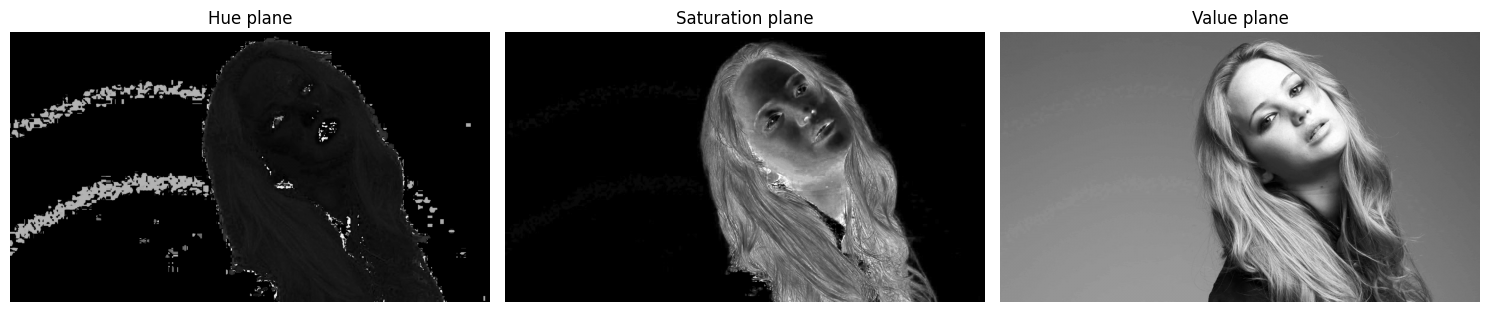

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(h, cmap='gray')
axes[0].set_title('Hue plane')
axes[0].axis('off')

axes[1].imshow(s, cmap='gray')
axes[1].set_title('Saturation plane')
axes[1].axis('off')

axes[2].imshow(v, cmap='gray')
axes[2].set_title('Value plane')
axes[2].axis('off')

plt.tight_layout()
plt.show()

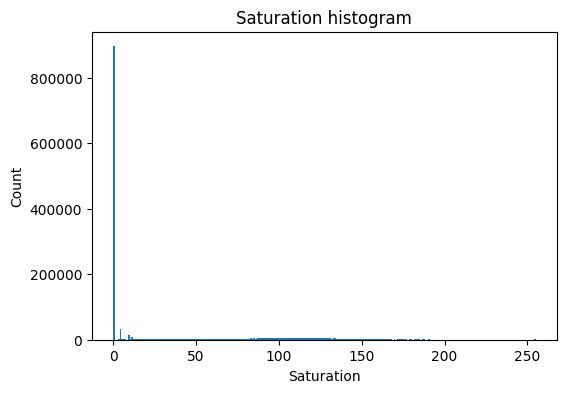

In [83]:
# check the saturation histogram first to help choose a threshold
plt.figure(figsize=(6,4))
plt.hist(s.ravel(), bins=256, range=(0,255))
plt.title('Saturation histogram')
plt.xlabel('Saturation')
plt.ylabel('Count')
plt.show()

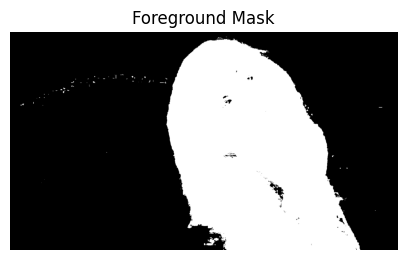

In [110]:
threshold_value = 12

_, mask = cv2.threshold(s, threshold_value, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(5,5))
plt.imshow(mask, cmap='gray')
plt.title('Foreground Mask')
plt.axis('off')
plt.show()

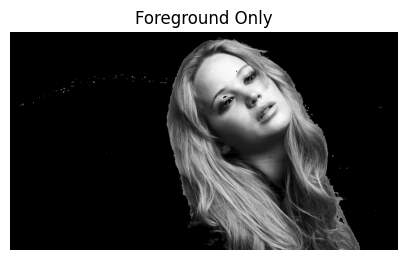

In [111]:
foreground = cv2.bitwise_and(img_gray, img_gray, mask=mask)

plt.figure(figsize=(5,5))
plt.imshow(foreground, cmap='gray')
plt.title('Foreground Only')
plt.axis('off')
plt.show()

In [112]:
# only count pixels where mask is white, ignore the zero background pixels
foreground_pixels = img_gray[mask == 255]

hist, bins = np.histogram(foreground_pixels, bins=256, range=(0,256))
cdf = np.cumsum(hist)
cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
cdf_normalized = cdf_normalized.astype(np.uint8)

foreground_equalized = np.zeros_like(img_gray)
foreground_equalized[mask == 255] = cdf_normalized[img_gray[mask == 255]]

In [113]:
mask_inv = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img_gray, img_gray, mask=mask_inv)

final_result = cv2.add(background, foreground_equalized)

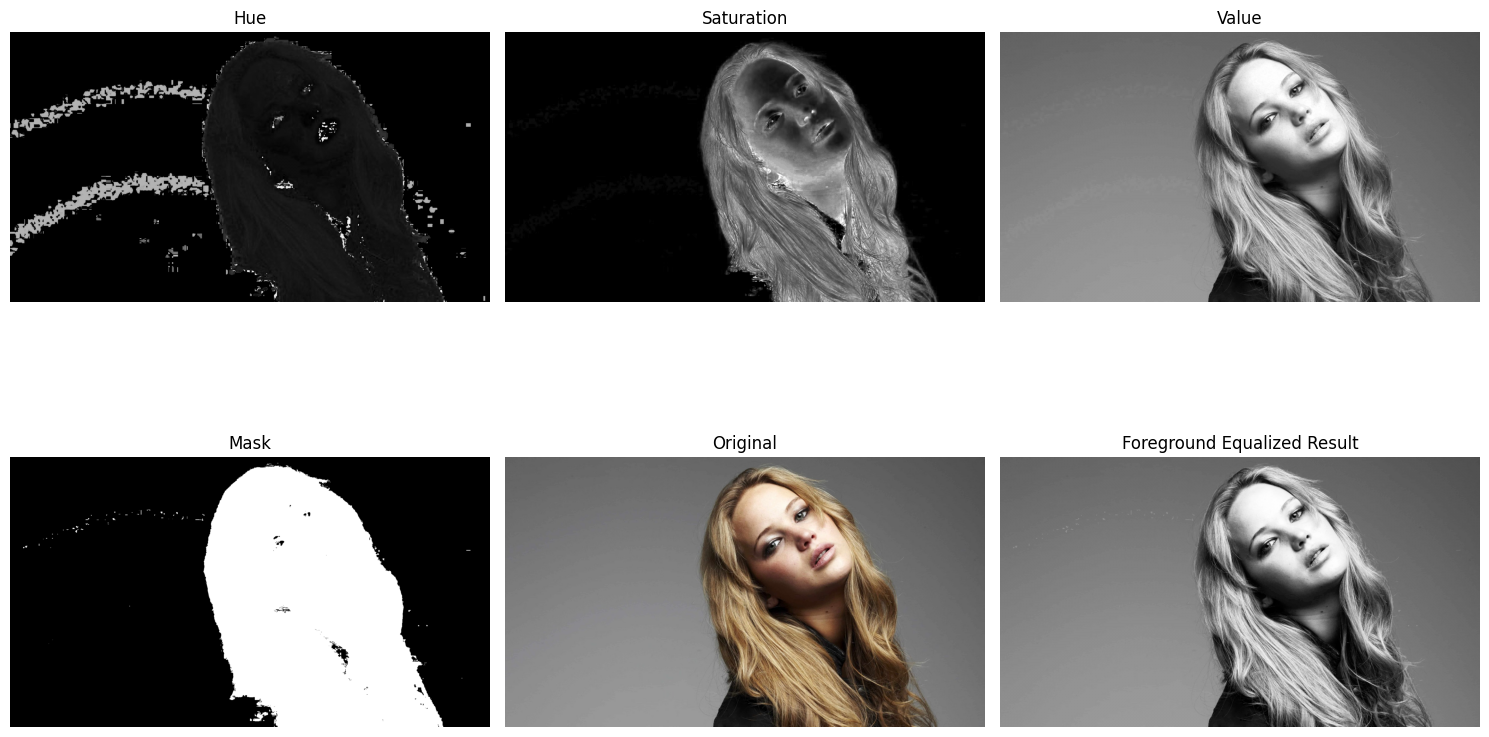

In [114]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

axes[0,0].imshow(h, cmap='gray')
axes[0,0].set_title('Hue')
axes[0,0].axis('off')

axes[0,1].imshow(s, cmap='gray')
axes[0,1].set_title('Saturation')
axes[0,1].axis('off')

axes[0,2].imshow(v, cmap='gray')
axes[0,2].set_title('Value')
axes[0,2].axis('off')

axes[1,0].imshow(mask, cmap='gray')
axes[1,0].set_title('Mask')
axes[1,0].axis('off')

axes[1,1].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[1,1].set_title('Original')
axes[1,1].axis('off')

axes[1,2].imshow(final_result, cmap='gray')
axes[1,2].set_title('Foreground Equalized Result')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

### Result and Discussion
The saturation plane gave the cleanest separation between the person and the
background, so it was used for thresholding. A threshold value of 12 worked
well for this image, giving a mask that covered the person's hair, skin and
clothing without including much of the background.

After equalizing only the foreground pixels, the final combined image shows
more contrast and detail in the person, especially in the hair, while the
background stayed exactly the same as the original since it was never
touched. This confirms the equalization was correctly applied to only the
selected region.

## Question 7: Sobel Filtering

### Aim
To compute the image gradient using the Sobel operator in three ways: using
OpenCV's filter2D, writing the convolution manually, and using the separable
property of the Sobel kernel.

### Method
The Sobel operator detects edges by approximating the image gradient. The
horizontal Sobel kernel picks up vertical edges (changes across columns) and
the vertical Sobel kernel picks up horizontal edges (changes across rows).

Horizontal kernel:
[1  0 -1]
[2  0 -2]
[1  0 -1]

Vertical kernel: the same kernel rotated 90 degrees, so
[ 1  2  1]
[ 0  0  0]
[-1 -2 -1]

Part (a) uses OpenCV's own filter2D function to apply this kernel directly.
Part (b) writes the sliding window convolution manually with loops, to show
what filter2D is actually doing internally.
Part (c) uses the fact that the Sobel kernel can be split into two smaller
1D kernels multiplied together (an outer product). This is called a
separable filter. Instead of doing one 3x3 convolution, we can do two 1D
convolutions instead, a column vector convolution followed by a row vector
convolution, which gives the same result but is cheaper to compute.

In [115]:
einstein = cv2.imread('/content/drive/MyDrive/EN3160/data/einstein.jpeg', cv2.IMREAD_GRAYSCALE)

if einstein is None:
    raise FileNotFoundError("image not found, check the path")

einstein_f = einstein.astype(np.float64)

In [121]:
sobel_x_kernel = np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=np.float64)

sobel_y_kernel = np.array([[1, 2, 1],
                            [0, 0, 0],
                            [-1, -2, -1]], dtype=np.float64)

grad_x = cv2.filter2D(einstein_f, -1, sobel_x_kernel, borderType=cv2.BORDER_CONSTANT)
grad_y = cv2.filter2D(einstein_f, -1, sobel_y_kernel, borderType=cv2.BORDER_CONSTANT)

gradient_magnitude_a = np.sqrt(grad_x**2 + grad_y**2)
gradient_magnitude_a = np.uint8(255 * gradient_magnitude_a / gradient_magnitude_a.max())

In [122]:
def manual_convolution(im, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(im, dtype=np.float64)

    rows, cols = im.shape
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output

grad_x_manual = manual_convolution(einstein_f, sobel_x_kernel)
grad_y_manual = manual_convolution(einstein_f, sobel_y_kernel)

gradient_magnitude_b = np.sqrt(grad_x_manual**2 + grad_y_manual**2)
gradient_magnitude_b = np.uint8(255 * gradient_magnitude_b / gradient_magnitude_b.max())

In [126]:
# sobel_x kernel splits into a column vector and a row vector
col_kernel = np.array([[1], [2], [1]], dtype=np.float64)
row_kernel = np.array([[1, 0, -1]], dtype=np.float64)

grad_x_sep = cv2.filter2D(einstein_f, -1, col_kernel, borderType=cv2.BORDER_CONSTANT)
grad_x_sep = cv2.filter2D(grad_x_sep, -1, row_kernel, borderType=cv2.BORDER_CONSTANT)

# same idea for the vertical kernel, just transpose the two 1D kernels
col_kernel_y = np.array([[1], [0], [-1]], dtype=np.float64)
row_kernel_y = np.array([[1, 2, 1]], dtype=np.float64)

grad_y_sep = cv2.filter2D(einstein_f, -1, col_kernel_y, borderType=cv2.BORDER_CONSTANT)
grad_y_sep = cv2.filter2D(grad_y_sep, -1, row_kernel_y, borderType=cv2.BORDER_CONSTANT)

gradient_magnitude_c = np.sqrt(grad_x_sep**2 + grad_y_sep**2)
gradient_magnitude_c = np.uint8(255 * gradient_magnitude_c / gradient_magnitude_c.max())

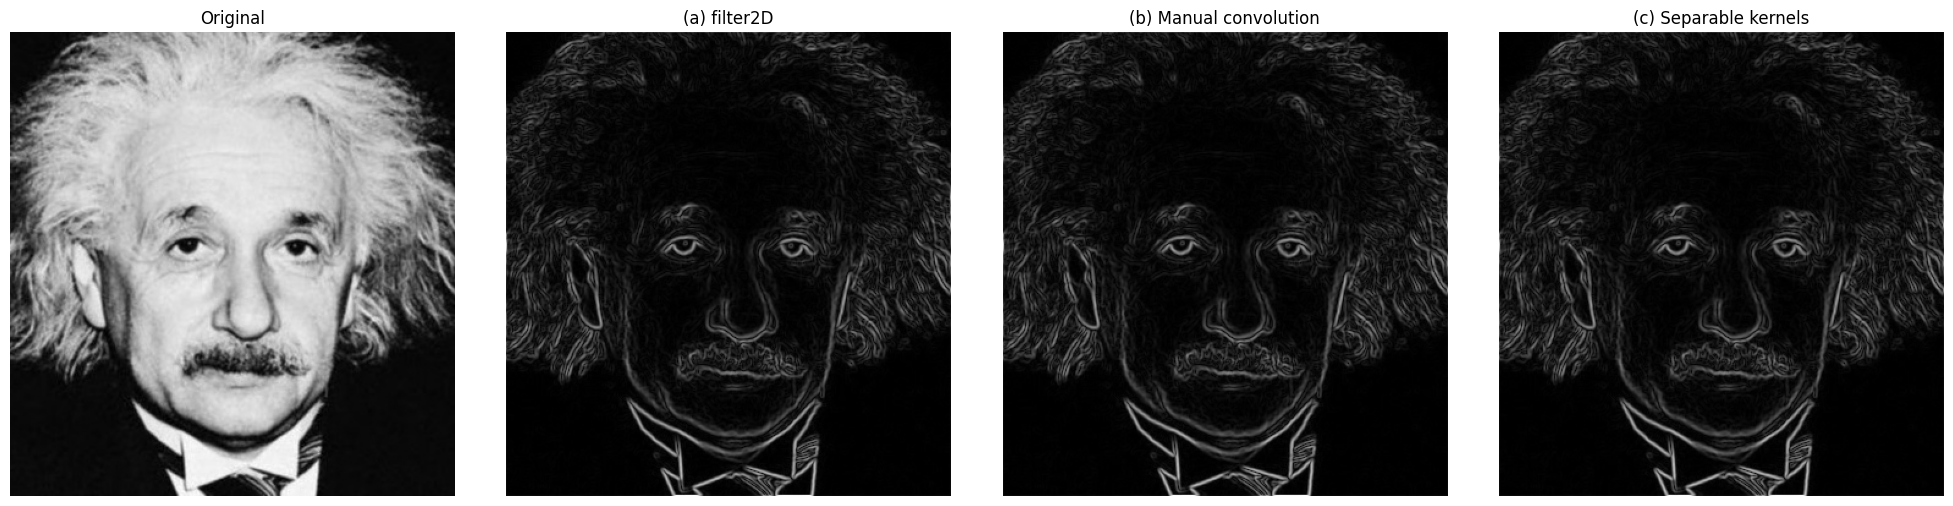

In [127]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

axes[0].imshow(einstein, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(gradient_magnitude_a, cmap='gray')
axes[1].set_title('(a) filter2D')
axes[1].axis('off')

axes[2].imshow(gradient_magnitude_b, cmap='gray')
axes[2].set_title('(b) Manual convolution')
axes[2].axis('off')

axes[3].imshow(gradient_magnitude_c, cmap='gray')
axes[3].set_title('(c) Separable kernels')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [128]:
diff_ab = np.abs(gradient_magnitude_a.astype(int) - gradient_magnitude_b.astype(int))
diff_ac = np.abs(gradient_magnitude_a.astype(int) - gradient_magnitude_c.astype(int))

print("Max difference between (a) and (b):", diff_ab.max())
print("Max difference between (a) and (c):", diff_ac.max())

Max difference between (a) and (b): 0
Max difference between (a) and (c): 0


### Result and Discussion
All three methods produced identical edge maps, showing clear outlines
around the face, hair and clothing in the Einstein image. The difference
check between all methods showed a max difference of 0, confirming that
filter2D, the manual convolution, and the separable kernel approach all
compute exactly the same result.

While testing this, I first got a large mismatch between filter2D and my
manual convolution, since filter2D uses reflected border padding by
default, while my manual function used zero padding. This border mismatch
changed the maximum gradient value used for normalization, which then
caused differences across the whole image, not just at the edges. Setting
borderType=cv2.BORDER_CONSTANT in filter2D, matching it to the same zero
padding used in the manual function, fixed this and brought the difference
down to zero. The same fix was needed for the separable kernel method as
well, since it also used filter2D internally.

The manual convolution method was noticeably slower to run than filter2D
and the separable approach, since it uses plain Python loops instead of
optimized C code. The separable method uses two 1D convolutions instead of
one 2D convolution, which is computationally cheaper, especially for larger
kernels, even though the result is mathematically identical.

## Question 8: Image Zooming

### Aim
To write a function that zooms an image by a given factor using nearest
neighbor and bilinear interpolation, and to test accuracy by scaling up
small images and comparing them with the original large images using
normalized SSD.

### Method
Zooming an image means creating a new image with a different size, where
each new pixel value has to be worked out from the original image, since
the new grid of pixels does not line up exactly with the old one.

For a zoom factor s, each output pixel position (i, j) is mapped back to a
position in the original image by dividing by s, giving (i/s, j/s). This
usually lands between actual pixels, not exactly on one, so we need a rule
to decide what value to use.

Nearest neighbor simply rounds this position to the closest actual pixel
and copies its value. This is fast but can look blocky, especially when
zooming in a lot.

Bilinear interpolation instead looks at the four nearest pixels around that
position, and blends them together using weights based on how close the
position is to each of the four pixels. This gives a smoother result than
nearest neighbor, since it accounts for the fractional position instead of
just rounding it away.

To test the two methods, small versions of two images were zoomed up by a
factor of 4 and compared against the original large versions using
normalized sum of squared differences (SSD), which measures how close the
zoomed result is to the true original, with lower values meaning a better
match.

In [129]:
def zoom_nearest_neighbor(im, s):
    h, w = im.shape[:2]
    new_h, new_w = int(round(h * s)), int(round(w * s))

    if im.ndim == 2:
        output = np.zeros((new_h, new_w), dtype=im.dtype)
    else:
        output = np.zeros((new_h, new_w, im.shape[2]), dtype=im.dtype)

    for i in range(new_h):
        for j in range(new_w):
            orig_i = min(int(round(i / s)), h - 1)
            orig_j = min(int(round(j / s)), w - 1)
            output[i, j] = im[orig_i, orig_j]

    return output

In [130]:
def zoom_bilinear(im, s):
    h, w = im.shape[:2]
    new_h, new_w = int(round(h * s)), int(round(w * s))

    im_f = im.astype(np.float64)

    if im.ndim == 2:
        output = np.zeros((new_h, new_w), dtype=np.float64)
    else:
        output = np.zeros((new_h, new_w, im.shape[2]), dtype=np.float64)

    for i in range(new_h):
        for j in range(new_w):
            orig_i = i / s
            orig_j = j / s

            i0 = int(np.floor(orig_i))
            j0 = int(np.floor(orig_j))
            i1 = min(i0 + 1, h - 1)
            j1 = min(j0 + 1, w - 1)
            i0 = min(i0, h - 1)
            j0 = min(j0, w - 1)

            di = orig_i - i0
            dj = orig_j - j0

            top = im_f[i0, j0] * (1 - dj) + im_f[i0, j1] * dj
            bottom = im_f[i1, j0] * (1 - dj) + im_f[i1, j1] * dj
            output[i, j] = top * (1 - di) + bottom * di

    return np.uint8(np.clip(output, 0, 255))

In [135]:
small_img1 = cv2.imread('/content/drive/MyDrive/EN3160/data/small3.png')
large_img1 = cv2.imread('/content/drive/MyDrive/EN3160/data/large3.png')

small_img2 = cv2.imread('/content/drive/MyDrive/EN3160/data/small2.png')
large_img2 = cv2.imread('/content/drive/MyDrive/EN3160/data/large2.png')

if small_img1 is None or large_img1 is None or small_img2 is None or large_img2 is None:
    raise FileNotFoundError("one or more images not found, check the paths")

In [136]:
zoomed_nn_1 = zoom_nearest_neighbor(small_img1, 4)
zoomed_bilinear_1 = zoom_bilinear(small_img1, 4)

zoomed_nn_2 = zoom_nearest_neighbor(small_img2, 4)
zoomed_bilinear_2 = zoom_bilinear(small_img2, 4)

In [137]:
def normalized_ssd(im1, im2):
    # make sure shapes match exactly before comparing
    h = min(im1.shape[0], im2.shape[0])
    w = min(im1.shape[1], im2.shape[1])
    im1_c = im1[:h, :w].astype(np.float64)
    im2_c = im2[:h, :w].astype(np.float64)

    ssd = np.sum((im1_c - im2_c) ** 2)
    normalized = ssd / (h * w * 255**2)
    return normalized

ssd_nn_1 = normalized_ssd(zoomed_nn_1, large_img1)
ssd_bilinear_1 = normalized_ssd(zoomed_bilinear_1, large_img1)

ssd_nn_2 = normalized_ssd(zoomed_nn_2, large_img2)
ssd_bilinear_2 = normalized_ssd(zoomed_bilinear_2, large_img2)

print("Image 1 - Nearest neighbor SSD:", ssd_nn_1)
print("Image 1 - Bilinear SSD:", ssd_bilinear_1)
print("Image 2 - Nearest neighbor SSD:", ssd_nn_2)
print("Image 2 - Bilinear SSD:", ssd_bilinear_2)

Image 1 - Nearest neighbor SSD: 0.0029817475583643043
Image 1 - Bilinear SSD: 0.002258854233414499
Image 2 - Nearest neighbor SSD: 0.005984501286257715
Image 2 - Bilinear SSD: 0.0045242134204898435


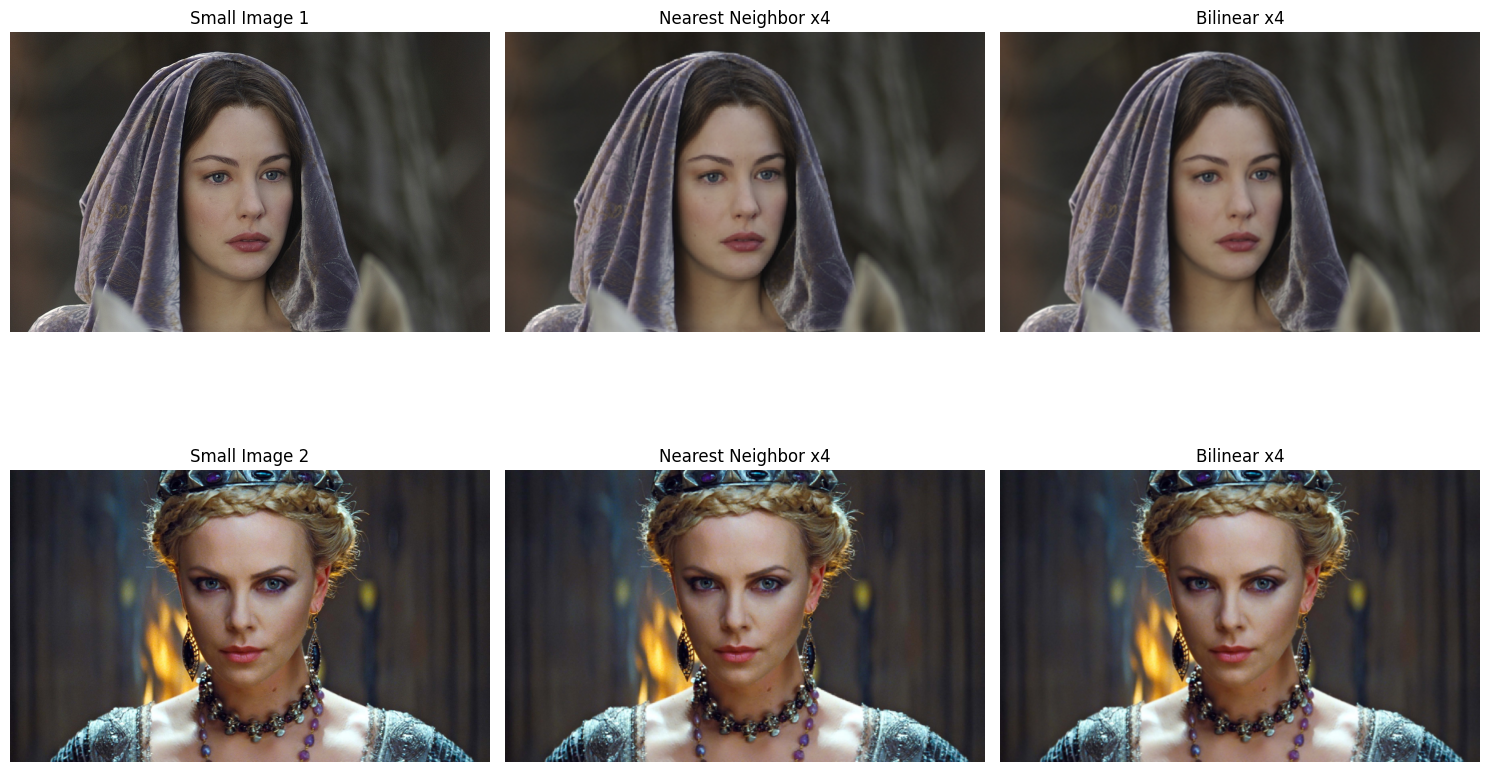

In [138]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

axes[0,0].imshow(cv2.cvtColor(small_img1, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('Small Image 1')
axes[0,0].axis('off')

axes[0,1].imshow(cv2.cvtColor(zoomed_nn_1, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('Nearest Neighbor x4')
axes[0,1].axis('off')

axes[0,2].imshow(cv2.cvtColor(zoomed_bilinear_1, cv2.COLOR_BGR2RGB))
axes[0,2].set_title('Bilinear x4')
axes[0,2].axis('off')

axes[1,0].imshow(cv2.cvtColor(small_img2, cv2.COLOR_BGR2RGB))
axes[1,0].set_title('Small Image 2')
axes[1,0].axis('off')

axes[1,1].imshow(cv2.cvtColor(zoomed_nn_2, cv2.COLOR_BGR2RGB))
axes[1,1].set_title('Nearest Neighbor x4')
axes[1,1].axis('off')

axes[1,2].imshow(cv2.cvtColor(zoomed_bilinear_2, cv2.COLOR_BGR2RGB))
axes[1,2].set_title('Bilinear x4')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

### Result and Discussion
Looking at the zoomed images, the nearest neighbor result looks blocky, with
visible square patches, especially around edges and curved shapes. The
bilinear result looks noticeably smoother, since it blends nearby pixels
instead of just copying one.

The normalized SSD scores confirm this numerically:

Image 1: nearest neighbor SSD = 0.00298, bilinear SSD = 0.00226

Image 2: nearest neighbor SSD = 0.00598, bilinear SSD = 0.00452

For both test images, bilinear interpolation gave a lower SSD than nearest
neighbor, meaning it more closely matches the original large image in both
cases. This confirms that bilinear interpolation is more accurate than
nearest neighbor for zooming, since it blends the four nearest pixels based
on fractional distance instead of just picking the closest one. Nearest
neighbor loses more detail because it cannot represent gradual changes in
intensity, it can only copy exact existing pixel values.

It is also worth noting that image 2 had a higher SSD than image 1 for both
methods. This suggests image 2 likely has more fine detail or texture that
is harder to recover accurately after being shrunk down and zoomed back up,
compared to image 1.